# **1. Import Necessary Libraries**

In [1]:
!pip install keras_tuner
!git clone https://github.com/clayton-h-costa/pv_fault_dataset.git

Cloning into 'pv_fault_dataset'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 24 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 26.69 MiB | 2.02 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.io import loadmat
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_recall_fscore_support, cohen_kappa_score,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
import shap
import tensorflow as tf
import joblib
from keras_tuner import RandomSearch

# **2. Data Loading**

In [3]:
# Load the dataset
elec_data = loadmat('pv_fault_dataset/dataset_elec.mat')
amb_data = loadmat('pv_fault_dataset/dataset_amb.mat')

# Extract variables
vdc1 = elec_data['vdc1'].flatten()
vdc2 = elec_data['vdc2'].flatten()
idc1 = elec_data['idc1'].flatten()
idc2 = elec_data['idc2'].flatten()

irr = amb_data['irr'].flatten()
pvt = amb_data['pvt'].flatten()
f_nv = amb_data['f_nv'].flatten()

# Create a DataFrame for easier analysis
df = pd.DataFrame({
    'vdc1': vdc1,
    'vdc2': vdc2,
    'idc1': idc1,
    'idc2': idc2,
    'irradiance': irr,
    'temperature': pvt,
    'fault_label': f_nv
})

df = df[df['fault_label'] != 2].copy()

In [4]:
# View the features
df.head()

,vdc1,vdc2,idc1,idc2,irradiance,temperature,fault_label
0,0.7143,0.5550,0.0608,0.0073,1.3729,2.3816,0
1,0.6944,0.5427,0.0615,0.0064,1.3604,2.3816,0
2,0.7110,0.5583,0.0646,0.0067,1.5118,2.3883,0
3,0.6991,0.5465,0.0628,0.0067,1.5534,2.3920,0
4,0.7035,0.5553,0.0606,0.0076,1.4355,2.3920,0


In [5]:
# Total samples
print("Total samples:", len(df))

Total samples: 1363427


In [6]:
# Label value counts
df['fault_label'].value_counts()

fault_label
0    1162931
4     188473
3       6024
1       5999
Name: count, dtype: int64

# **3. Data Preprocessing**

In [7]:
# Add calculated columns
df['power_string1'] = df['vdc1'] * df['idc1']
df['power_string2'] = df['vdc2'] * df['idc2']
df['total_power'] = df['power_string1'] + df['power_string2']
df['voltage_ratio'] = df['vdc1'] / df['vdc2']
df['current_ratio'] = df['idc1'] / df['idc2']

print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {len(df)}")

# Create fault name mapping
fault_names = {
    0: 'Normal Operation',
    1: 'Short-Circuit',
    3: 'Open Circuit',
    4: 'Shadowing'
}

# Add fault name column
df['fault_label'] = df['fault_label'].map(fault_names)

Dataset shape: (1363427, 12)
Number of samples: 1363427


In [8]:
df.head()

,vdc1,vdc2,idc1,idc2,irradiance,temperature,fault_label,power_string1,power_string2,total_power,voltage_ratio,current_ratio
0,0.7143,0.5550,0.0608,0.0073,1.3729,2.3816,Normal Operation,0.043429,0.004052,0.047481,1.287027,8.328767
1,0.6944,0.5427,0.0615,0.0064,1.3604,2.3816,Normal Operation,0.042706,0.003473,0.046179,1.279528,9.609375
2,0.7110,0.5583,0.0646,0.0067,1.5118,2.3883,Normal Operation,0.045931,0.003741,0.049671,1.273509,9.641791
3,0.6991,0.5465,0.0628,0.0067,1.5534,2.3920,Normal Operation,0.043903,0.003662,0.047565,1.279231,9.373134
4,0.7035,0.5553,0.0606,0.0076,1.4355,2.3920,Normal Operation,0.042632,0.004220,0.046852,1.266883,7.973684


# **4. Train Test Splitting**

In [9]:
# Seperate data
X = df.drop(['fault_label'], axis=1).values
y_labels = df['fault_label'].values

In [10]:
print("X Shape:", X.shape)

X Shape: (1363427, 11)


In [11]:
print("y Shape:", y_labels.shape)

y Shape: (1363427,)


In [12]:
X_train, X_test, y_train_lbl, y_test_lbl = train_test_split(
    X, y_labels,
    test_size=0.2,
    stratify=y_labels,
    random_state=42
)

In [13]:
ohe = OneHotEncoder()
y_train = ohe.fit_transform(y_train_lbl.reshape(-1, 1)).toarray()
y_test  = ohe.transform(y_test_lbl.reshape(-1, 1)).toarray()

In [14]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Standard Scaler Justification**

In here, standard scaler is used to ensure all features contribute equally to the target.
Transformed and fitted for X train, and transformed X test to prevent data leakage.

In [15]:
# Show the shapes
print("X train shape:", X_train.shape)
print("X test shape:", X_test.shape)

X train shape: (1090741, 11)
X test shape: (272686, 11)


In [16]:
# View total samples
print("Training set:", len(X_train),"samples")
print("Testing set:", len(X_test),"samples")

Training set: 1090741 samples
Testing set: 272686 samples


In [17]:
y_classes = np.argmax(y_train, axis=1)
classes = np.unique(y_classes)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_classes)
class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(0.2931015301866836), np.int64(1): np.float64(56.585443037974684), np.int64(2): np.float64(1.808509474131013), np.int64(3): np.float64(56.82126484684309)}


# **5. Building the Neural Network**

In [18]:
def build_ann(input_dim, output_dim):
  """
  Builds a neural network model for fault detection
  """

  model = tf.keras.models.Sequential([
      # Define input
      tf.keras.layers.Input((input_dim, )),

      # Hidden layer #1
      tf.keras.layers.Dense(128, activation='relu'),
      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Dropout(0.2),

      # Hidden layer # 2
      tf.keras.layers.Dense(64, activation='relu'),
      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Dropout(0.2),

      # Hidden layer # 3
      tf.keras.layers.Dense(32, activation='relu'),
      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Dropout(0.2),

      # Define output layer
      tf.keras.layers.Dense(output_dim, activation='softmax')
  ])

  return model

In [19]:
# Define input and output shapes
input_dim = X_train.shape[1]
output_dim = y_train.shape[1]

In [20]:
print("Input dim:", input_dim)

Input dim: 11


In [21]:
print("Output dim:", output_dim)

Output dim: 4


In [22]:
# Build the ANN
ann = build_ann(input_dim, output_dim)

In [23]:
# Compile model
ann.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',  # use categorical cross entropy for one hot encoded labels
    metrics=[
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc')
    ]
)

In [24]:
# Show the models' summary
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,900 (50.39 KB)

 Trainable params: 12,452 (48.64 KB)

 Non-trainable params: 448 (1.75 KB)

# **6. Training the Neural Network**

In [25]:
# Define call backs for early stopping
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=7,    # stop after 10 epochs if no improvement
        restore_best_weights=True # return back to the best model
    )
]

# Fit the ANN
history = ann.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/20
34086/34086 ━━━━━━━━━━━━━━━━━━━━ 35s 989us/step - accuracy: 0.9473 - auc: 0.9953 - loss: 0.0778 - precision: 0.9501 - recall: 0.9447 - val_accuracy: 0.9794 - val_auc: 0.9995 - val_loss: 0.0514 - val_precision: 0.9794 - val_recall: 0.9794
Epoch 2/20
34086/34086 ━━━━━━━━━━━━━━━━━━━━ 33s 975us/step - accuracy: 0.9742 - auc: 0.9984 - loss: 0.0444 - precision: 0.9745 - recall: 0.9740 - val_accuracy: 0.9904 - val_auc: 0.9998 - val_loss: 0.0338 - val_precision: 0.9904 - val_recall: 0.9904
Epoch 3/20
34086/34086 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - accuracy: 0.9778 - auc: 0.9987 - loss: 0.0389 - precision: 0.9780 - recall: 0.9776 - val_accuracy: 0.9920 - val_auc: 0.9998 - val_loss: 0.0297 - val_precision: 0.9920 - val_recall: 0.9920
Epoch 4/20
34086/34086 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - accuracy: 0.9823 - auc: 0.9991 - loss: 0.0313 - precision: 0.9825 - recall: 0.9822 - val_accuracy: 0.9884 - val_auc: 0.9997 - val_loss: 0.0406 - val_precision: 0.9884 - val_recall: 0.9884
Epoch 5/

# **7. Evaluate Neural Network**

In [26]:
# Get predictions
y_pred_proba = ann.predict(X_test, verbose=0)

In [27]:
y_pred = np.argmax(y_pred_proba, axis=1)

In [28]:
y_true = np.argmax(y_test, axis=1)

In [29]:
classes = np.unique(y_true)
y_test_bin = label_binarize(y_true, classes=classes)

# **8. Display Results**

In [30]:
def display_history(history):
  """
  Plots the ANN's training metrics
  """

  fig, axes = plt.subplots(2, 3, figsize=(15, 10))

  plt.suptitle('Plots of All Neural Network\'s Metrics', fontsize=20, fontweight='bold')

  # Accuracy
  axes[0, 0].plot(history.history['accuracy'], label='Train', c='blue')
  axes[0, 0].plot(history.history['val_accuracy'], label='Validation', c='red')
  axes[0, 0].set_title('ANN Accuracy')
  axes[0, 0].set_ylabel('Accuracy')
  axes[0, 0].set_xlabel('Epoch')
  axes[0, 0].legend()

  # Loss
  axes[0, 1].plot(history.history['loss'], label='Train', c='blue')
  axes[0, 1].plot(history.history['val_loss'], label='Validation', c='red')
  axes[0, 1].set_title('ANN Loss')
  axes[0, 1].set_ylabel('Loss')
  axes[0, 1].set_xlabel('Epoch')
  axes[0, 1].legend()

  # Precision
  axes[0, 2].plot(history.history['precision'], label='Train', c='blue')
  axes[0, 2].plot(history.history['val_precision'], label='Validation', c='red')
  axes[0, 2].set_title('ANN Precision')
  axes[0, 2].set_ylabel('Precision')
  axes[0, 2].set_xlabel('Epoch')
  axes[0, 2].legend()

  # Recall
  axes[1, 0].plot(history.history['recall'], label='Train', c='blue')
  axes[1, 0].plot(history.history['val_recall'], label='Validation', c='red')
  axes[1, 0].set_title('ANN Recall')
  axes[1, 0].set_ylabel('Recall')
  axes[1, 0].set_xlabel('Epoch')
  axes[1, 0].legend()

  # AUC
  axes[1, 1].plot(history.history['auc'], label='Train', c='blue')
  axes[1, 1].plot(history.history['val_auc'], label='Validation', c='red')
  axes[1, 1].set_title('ANN AUC')
  axes[1, 1].set_ylabel('AUC')
  axes[1, 1].set_xlabel('Epoch')
  axes[1, 1].legend()

  plt.tight_layout()
  plt.show()

In [31]:
acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0)

kappa = cohen_kappa_score(y_true, y_pred)
roc_auc = roc_auc_score(y_test_bin, y_pred_proba, average="macro", multi_class="ovr")
pr_auc  = average_precision_score(y_test_bin, y_pred_proba, average="macro")

print("\n=== ANN PERFORMANCE ===")
print("Accuracy:", acc)
print("Precision_macro:", prec)
print("Recall_macro:", rec)
print("F1_macro:", f1)
print("Cohen Kappa:", kappa)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)


=== ANN PERFORMANCE ===
Accuracy: 0.9938317332022912
Precision_macro: 0.988772330192324
Recall_macro: 0.9915589165686425
F1_macro: 0.9901430164763088
Cohen Kappa: 0.975644901033143
ROC-AUC: 0.9989657605402666
PR-AUC: 0.9982727971408207


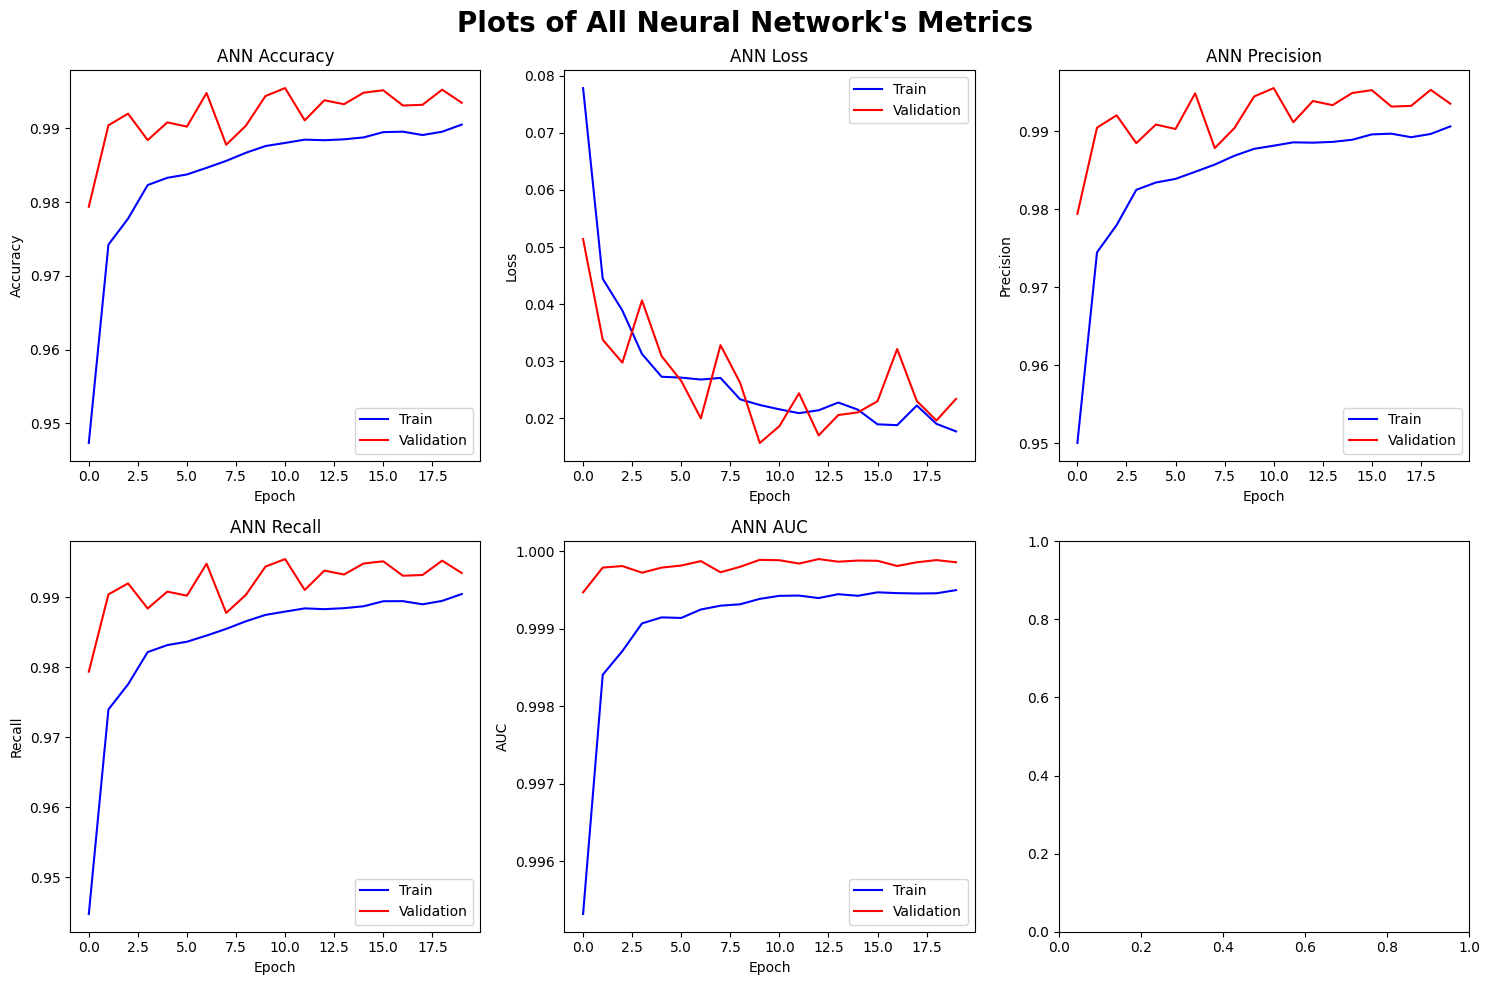

In [32]:
# Display the ANN's history
display_history(history)

Macro ROC-AUC: 0.9989657605402666
Macro PR-AUC: 0.9982727971408207


<Figure size 1000x500 with 0 Axes>

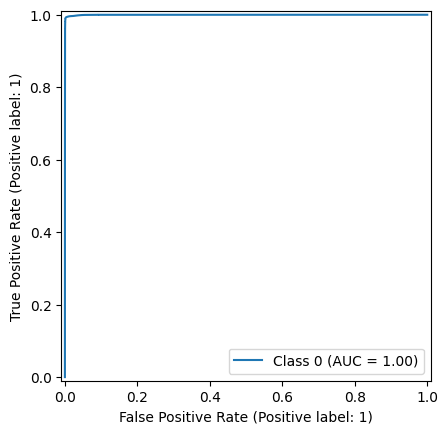

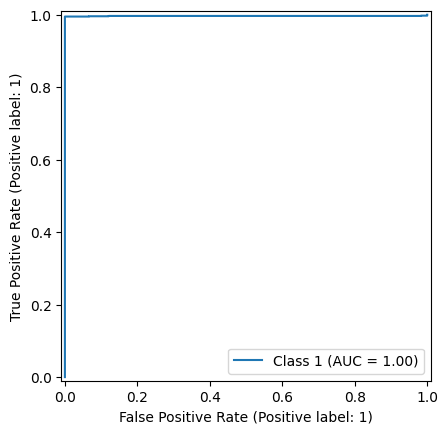

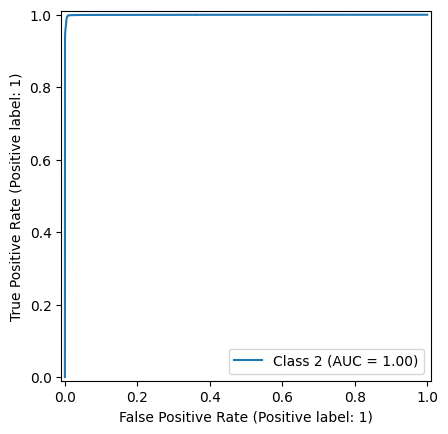

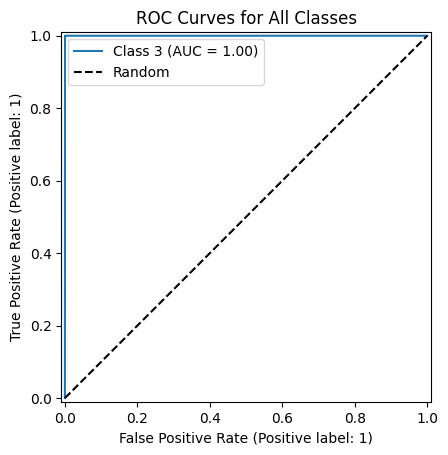

<Figure size 1000x500 with 0 Axes>

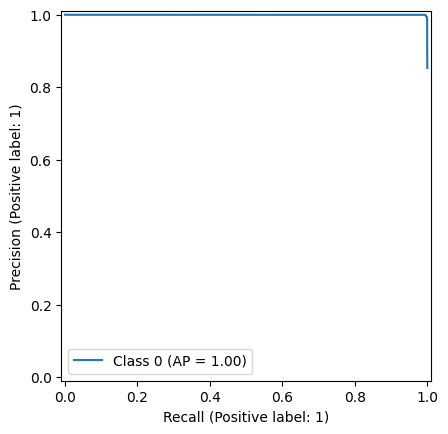

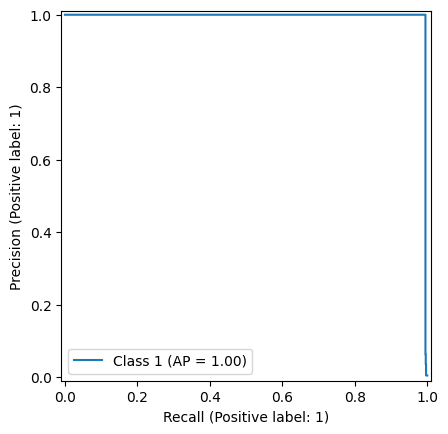

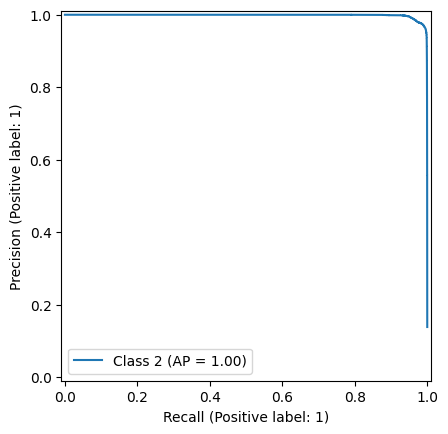

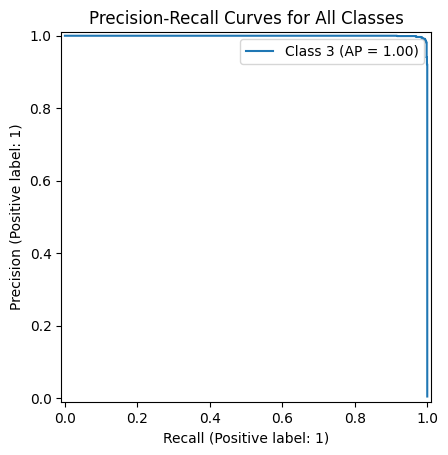

In [33]:
# Compute macro ROC-AUC
roc_auc = roc_auc_score(y_test_bin, y_pred_proba, average='macro', multi_class='ovr')
print("Macro ROC-AUC:", roc_auc)

# Compute macro PR-AUC
pr_auc = average_precision_score(y_test_bin, y_pred_proba, average='macro')
print("Macro PR-AUC:", pr_auc)

# Optional: Plot ROC and PR curves for each class
plt.figure(figsize=(10,5))
for i, cls in enumerate(classes):
    RocCurveDisplay.from_predictions(y_test_bin[:,i], y_pred_proba[:,i], name=f"Class {cls}")
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.title('ROC Curves for All Classes')
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
for i, cls in enumerate(classes):
    PrecisionRecallDisplay.from_predictions(y_test_bin[:,i], y_pred_proba[:,i], name=f"Class {cls}")
plt.title('Precision-Recall Curves for All Classes')
plt.legend()
plt.show()

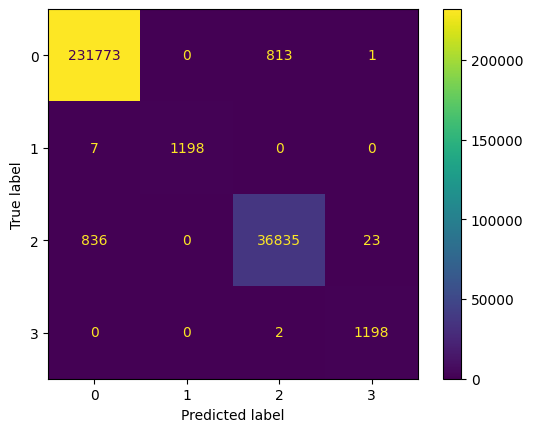

In [34]:
# Visualize confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [35]:
# View classification report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    232587
           1       1.00      0.99      1.00      1205
           2       0.98      0.98      0.98     37694
           3       0.98      1.00      0.99      1200

    accuracy                           0.99    272686
   macro avg       0.99      0.99      0.99    272686
weighted avg       0.99      0.99      0.99    272686



# **9. Hyperparameter Tuning**

In [36]:
def tune(parameter):
    """
    Build ANN model with tunable hyperparameters
    Suitable for multi-class imbalanced classification
    Uses Keras Tuner (RandomSearch / Bayesian / Hyperband)
    """

    # Initialize Sequential model
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))

    # Tunable number of hidden layers
    n_layers = parameter.Int('num_layers', min_value=1, max_value=3)

    # Shared hyperparameters across all hidden layers
    # L2 regularization helps reduce overfitting
    l2_value = parameter.Float('l2', 1e-5, 1e-1, sampling='log')

    # Dropout rate between 10% and 50%
    dropout_rate = parameter.Float('dropout', 0.1, 0.5, step=0.1)

    # Build hidden layers
    for i in range(n_layers):

        # Tunable number of neurons per layer
        units = parameter.Int(
            f'units_layer_{i}',
            min_value=32,
            max_value=256,
            step=32
        )

        # Fully connected Dense layer
        model.add(tf.keras.layers.Dense(
            units=units,
            activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(l2_value)
        ))

        # Batch Normalization to stabilize training
        model.add(tf.keras.layers.BatchNormalization())

        # Dropout to reduce overfitting
        model.add(tf.keras.layers.Dropout(dropout_rate))

    # Output layer
    # Softmax is used for multi class classification
    model.add(tf.keras.layers.Dense(output_dim, activation='softmax'))

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            # Tunable learning rate
            learning_rate=parameter.Float(
                'learning_rate', 1e-4, 1e-2, sampling='log'
            )
        ),

        # Categorical crossentropy for multi-class classification
        loss='categorical_crossentropy',

        metrics=[
            'accuracy',  # Overall correctness

            # Proportion of correct positive predictions
            tf.keras.metrics.Precision(name='precision'),

            # Capture minority classes
            tf.keras.metrics.Recall(name='recall'),

            # Suitable for imbalanced datasets
            tf.keras.metrics.AUC(name='auc')
        ]
    )

    return model


In [37]:
# Run hyparapemeter search
tuner = RandomSearch(
    tune,
    objective='val_auc', # targetting val auc, optimize it to the maximum
    max_trials=5,    # test upto 5 different hyperparameter combinations
    directory='fault_detection/tuner_results'
)

In [38]:
# Perform searching
tuner.search(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=7,
        restore_best_weights=True,
        mode='max'    # Highest is always best
    )],
    verbose=1,
    class_weight=class_weights
)

Trial 5 Complete [00h 05m 28s]
val_auc: 0.9997711181640625

Best val_auc So Far: 0.99994957447052
Total elapsed time: 00h 51m 36s


In [39]:
# Get the best parameters
best_hyper_params = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
best_hyper_params.values

Best hyperparameters:


{'num_layers': 2,
 'l2': 1.3565763816148619e-05,
 'dropout': 0.4,
 'units_layer_0': 96,
 'learning_rate': 0.00011238733253033597,
 'units_layer_1': 32}

In [40]:
# Best layers
print("Best number of layers:", best_hyper_params.get('num_layers'))

Best number of layers: 2


In [41]:
# Iterate through architecture
for i in range(best_hyper_params.get('num_layers')):
  print(f"Best number of units in layer:", best_hyper_params.get(f'units_layer_{i}'))
  print("Best dropout rate:", best_hyper_params.get('dropout'))
  print("Best learning rate:", best_hyper_params.get('learning_rate'))

Best number of units in layer: 96
Best dropout rate: 0.4
Best learning rate: 0.00011238733253033597
Best number of units in layer: 32
Best dropout rate: 0.4
Best learning rate: 0.00011238733253033597


# **10. Train the Best Model**

In [42]:
# Build using best params
best_model = tuner.hypermodel.build(best_hyper_params)

In [43]:
# Train the best model
history = best_model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=7,
        restore_best_weights=True,
        mode='max'
    )],
    verbose=1,
    class_weight=class_weights
)

Epoch 1/20
34086/34086 ━━━━━━━━━━━━━━━━━━━━ 28s 793us/step - accuracy: 0.8392 - auc: 0.9605 - loss: 0.2566 - precision: 0.8626 - recall: 0.8182 - val_accuracy: 0.9635 - val_auc: 0.9990 - val_loss: 0.0724 - val_precision: 0.9637 - val_recall: 0.9633
Epoch 2/20
34086/34086 ━━━━━━━━━━━━━━━━━━━━ 27s 780us/step - accuracy: 0.9579 - auc: 0.9969 - loss: 0.0645 - precision: 0.9588 - recall: 0.9568 - val_accuracy: 0.9810 - val_auc: 0.9996 - val_loss: 0.0461 - val_precision: 0.9810 - val_recall: 0.9810
Epoch 3/20
34086/34086 ━━━━━━━━━━━━━━━━━━━━ 27s 778us/step - accuracy: 0.9710 - auc: 0.9984 - loss: 0.0456 - precision: 0.9714 - recall: 0.9705 - val_accuracy: 0.9889 - val_auc: 0.9998 - val_loss: 0.0292 - val_precision: 0.9889 - val_recall: 0.9889
Epoch 4/20
34086/34086 ━━━━━━━━━━━━━━━━━━━━ 26s 760us/step - accuracy: 0.9766 - auc: 0.9988 - loss: 0.0401 - precision: 0.9769 - recall: 0.9762 - val_accuracy: 0.9887 - val_auc: 0.9998 - val_loss: 0.0300 - val_precision: 0.9887 - val_recall: 0.9887
Epoc

In [44]:
# Best model predictions
y_pred_proba_best = best_model.predict(X_test, verbose=0)
y_pred_best = np.argmax(y_pred_proba_best, axis=1)

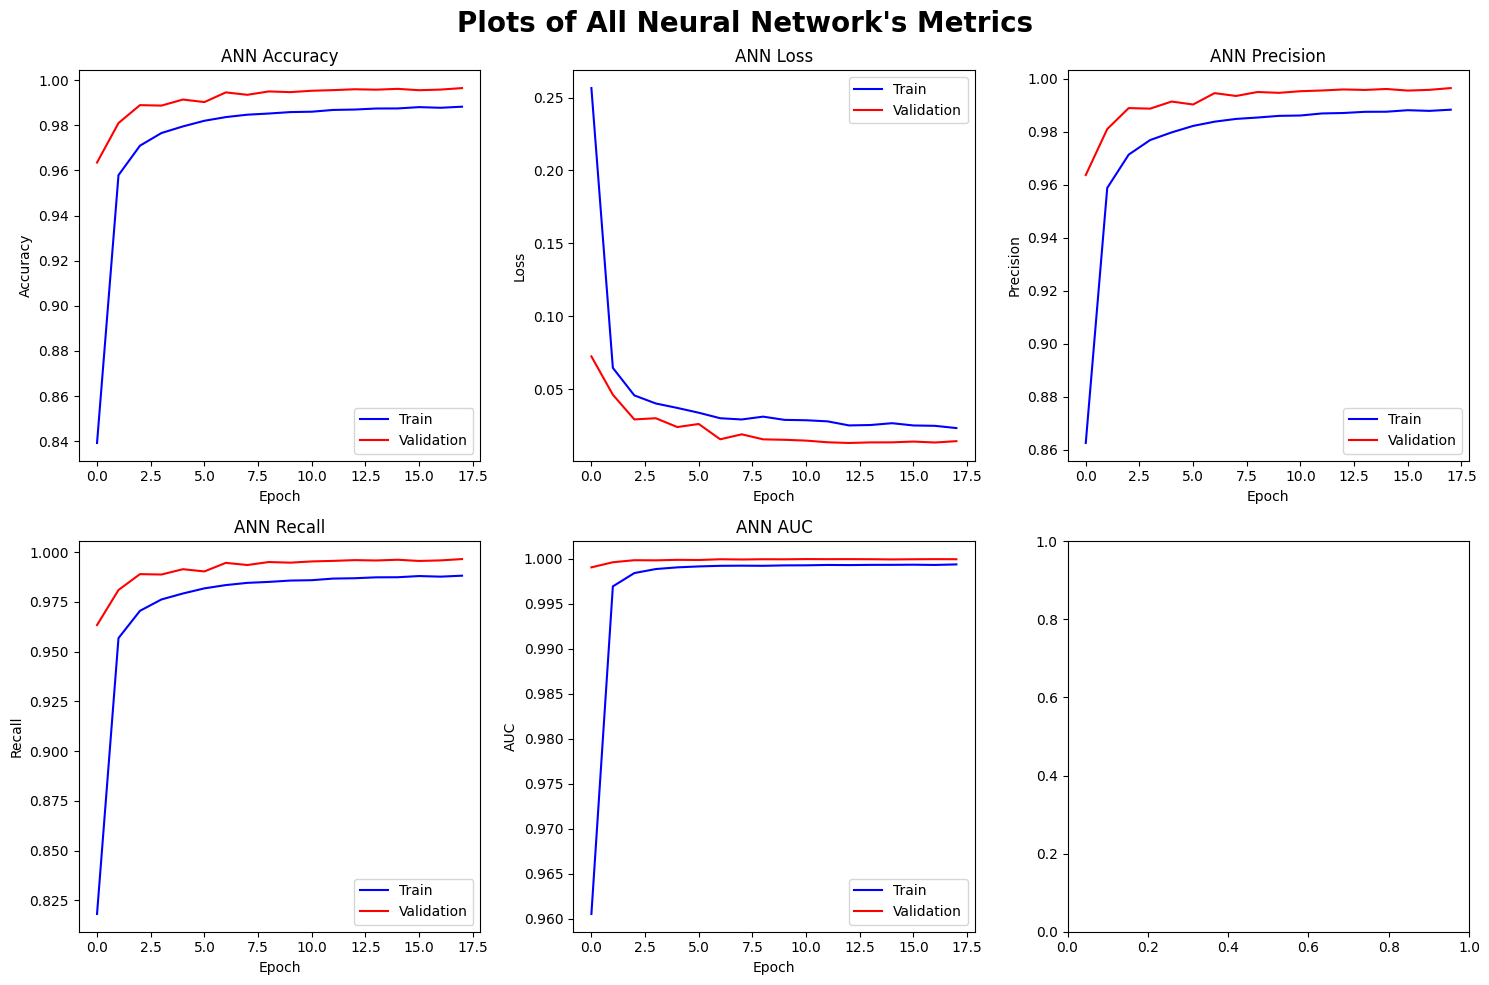

In [45]:
# Show the history
display_history(history)

Macro ROC-AUC: 0.9999411353809934
Macro PR-AUC: 0.9993904238222326


<Figure size 1000x500 with 0 Axes>

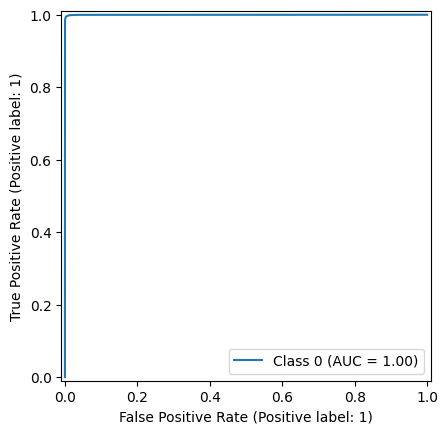

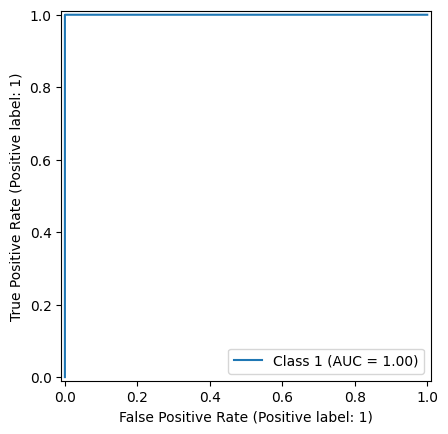

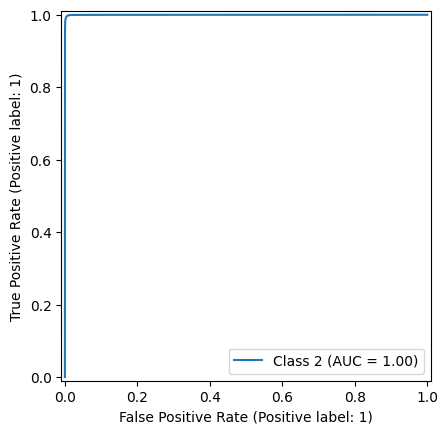

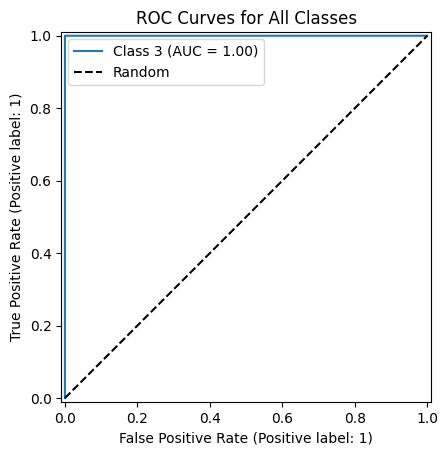

<Figure size 1000x500 with 0 Axes>

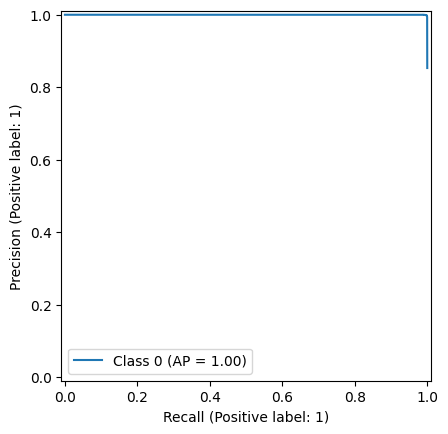

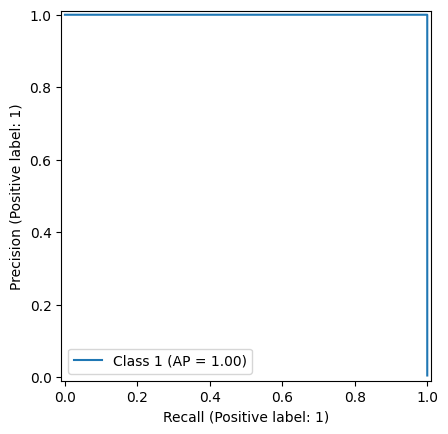

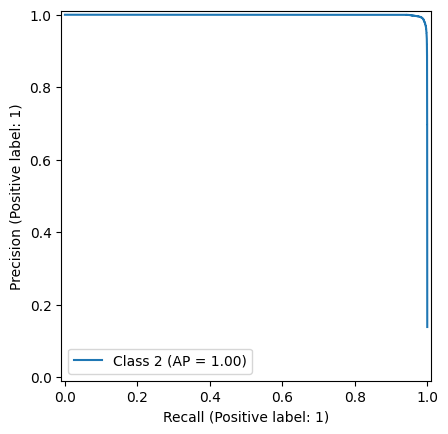

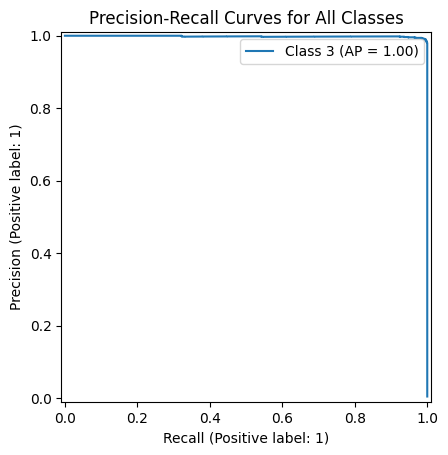

In [46]:
# Compute macro ROC-AUC
roc_auc = roc_auc_score(y_test_bin, y_pred_proba_best, average='macro', multi_class='ovr')
print("Macro ROC-AUC:", roc_auc)

# Compute macro PR-AUC
pr_auc = average_precision_score(y_test_bin, y_pred_proba_best, average='macro')
print("Macro PR-AUC:", pr_auc)

# Optional: Plot ROC and PR curves for each class
plt.figure(figsize=(10,5))
for i, cls in enumerate(classes):
    RocCurveDisplay.from_predictions(y_test_bin[:,i], y_pred_proba_best[:,i], name=f"Class {cls}")
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.title('ROC Curves for All Classes')
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
for i, cls in enumerate(classes):
    PrecisionRecallDisplay.from_predictions(y_test_bin[:,i], y_pred_proba_best[:,i], name=f"Class {cls}")
plt.title('Precision-Recall Curves for All Classes')
plt.legend()
plt.show()

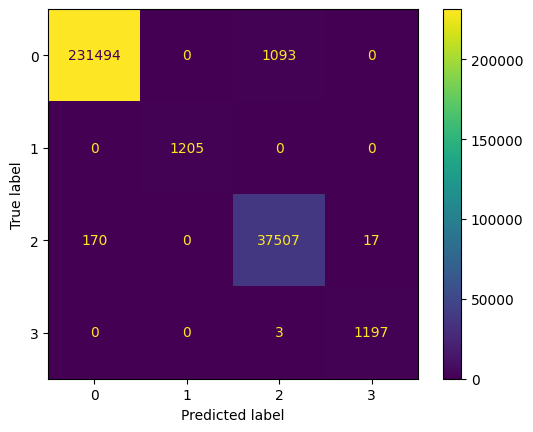

In [47]:
# Display confusion matrix
cm = confusion_matrix(y_true, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [48]:
# Classification report
print(classification_report(y_true, y_pred_best))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    232587
           1       1.00      1.00      1.00      1205
           2       0.97      1.00      0.98     37694
           3       0.99      1.00      0.99      1200

    accuracy                           1.00    272686
   macro avg       0.99      1.00      0.99    272686
weighted avg       1.00      1.00      1.00    272686



In [49]:
# Evaluate on test set
test_results = best_model.evaluate(X_test, y_test, verbose=0)

metrics = ['Loss', 'Accuracy', 'Precision', 'Recall', 'AUC']

df_results = pd.DataFrame(
  [np.round(test_results, 3)],
  columns=[f'Test {m}' for m in metrics]
)
df_results

,Test Loss,Test Accuracy,Test Precision,Test Recall,Test AUC
0,0.015,0.995,0.995,0.995,1.0


In [50]:
acc = accuracy_score(y_true, y_pred_best)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred_best, average="macro", zero_division=0)

kappa = cohen_kappa_score(y_true, y_pred_best)
roc_auc = roc_auc_score(y_test_bin, y_pred_proba_best, average="macro", multi_class="ovr")
pr_auc  = average_precision_score(y_test_bin, y_pred_proba_best, average="macro")

print("\n=== BEST ANN PERFORMANCE ===")
print("Accuracy:", acc)
print("Precision_macro:", prec)
print("Recall_macro:", rec)
print("F1_macro:", f1)
print("Cohen Kappa:", kappa)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)


=== BEST ANN PERFORMANCE ===
Accuracy: 0.9952949546364683
Precision_macro: 0.9892178269815783
Recall_macro: 0.9969599203585687
F1_macro: 0.9930446551087424
Cohen Kappa: 0.9816035691755226
ROC-AUC: 0.9999411353809934
PR-AUC: 0.9993904238222326


# **11. SHAP Interpretability**

In [51]:
# Background for shap
background = shap.sample(X_train, 100)

In [52]:
# Create the explainer
explainer = shap.KernelExplainer(best_model.predict, background)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [53]:
# Generate SHAP values
shap_vals = explainer.shap_values(X_test[:100]) # for speed efficiency, keep it to 100.

  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 2s 254us/step


  1%|          | 1/100 [00:02<04:24,  2.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 2s 244us/step


  2%|▏         | 2/100 [00:04<04:00,  2.45s/it]

...

 98%|█████████▊| 98/100 [03:45<00:04,  2.30s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 2s 243us/step


 99%|█████████▉| 99/100 [03:47<00:02,  2.29s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 2s 243us/step


100%|██████████| 100/100 [03:49<00:00,  2.30s/it]


In [54]:
# Feature names
feats = df.drop(['fault_label'], axis=1).columns

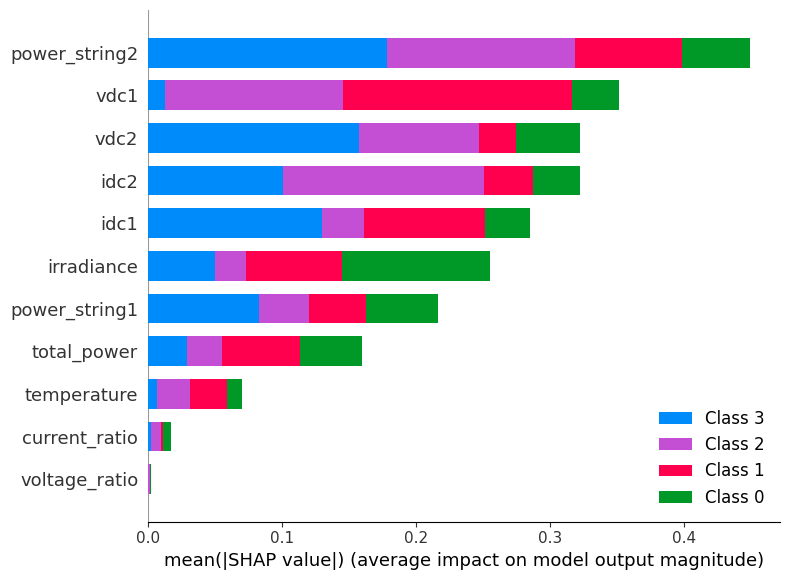

<Figure size 640x480 with 0 Axes>

In [55]:
# Summary plot
shap.summary_plot(
    shap_vals,
    X_test[:100],
    feature_names=feats,
    plot_type='bar'
)
plt.tight_layout()
plt.show()

In [56]:
# Force plot for a single prediction
shap.initjs()
shap.force_plot(explainer.expected_value[0], # Base value for the first output class
                shap_vals[0, :, 0],   # Take the SHAP values for the first sample, all features, first output class
                X_test[0],            # Actual feature values for the first sample
                feature_names=feats)

# **12. Save Best Model**

In [57]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [58]:
with open("history.pkl", 'wb') as f:
    joblib.dump(history, f)

In [59]:
best_model.save('best_neural_network.keras')